In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dadapy.plot import plot_inf_imb_plane
from dadapy.metric_comparisons import MetricComparisons

%matplotlib inline

%load_ext autoreload
%autoreload 2

# Load the heavy atom distances and the dihedrals

### Heavy atom distances

In [2]:
# #make into npy file, faster to load

# dist = np.loadtxt('./cln025_noPBC_dist.colvar')
# np.save('./cln025_noPBC_dist.colvar.npy', dist)

In [5]:
dist1=np.load('../../Kernel_Imbalance/examples/cln025_noPBC_dist.colvar.npy')

In [6]:
dist1
di=dist1[:,1:]
print(di.shape)
dis=di[::10]
print(dis.shape)

(41580, 4278)
(4158, 4278)


### Dihdedrals

In [8]:
cv_ori = np.loadtxt('../../Kernel_Imbalance/examples/cln025_noPBC_allframes.colvar')
#this is all dihedrals
cv_rad=cv_ori[:,2:]

#convert them from rad to degrees, because I prefer that :)
cv1=cv_rad*(180/np.pi)
for i in range(len(cv1[0])):
    cv1[:,i]=cv1[:,i]%360
cv1.shape

(41580, 32)

In [9]:
#clean away certain columns:
#chi2_5:
cv2= np.delete(cv1,29,1)
#ch2_3:
cv3= np.delete(cv2,28,1)
#chi1_5:
cv4= np.delete(cv3,21,1)
cv=cv4[::10]
cv.shape

(4158, 29)

In [10]:
cv

array([[317.73, 241.11, 281.09, ...,  71.25, 111.75, 287.42],
       [216.26, 225.87, 299.7 , ...,  75.85,  71.26, 111.53],
       [237.03, 264.24, 280.94, ...,  67.01,  98.86, 260.12],
       ...,
       [ 64.09, 207.77, 281.98, ..., 136.16, 273.23,  91.45],
       [200.56, 202.38, 293.65, ..., 260.11,  98.71, 278.45],
       [ 66.37, 210.52, 303.9 , ..., 105.42, 230.66,  83.99]])

In [11]:
names=["phi1","phi2","phi3","phi4","phi5","phi6","phi7","phi8","phi9","psi1","psi2","psi3","psi4","psi5","psi6","psi7","psi8","psi9","chi1_1","chi1_2","chi1_3","chi1_6","chi1_8","chi1_9","chi1_10","chi2_1","chi2_2","chi2_9","chi2_10"]
len(names)

29

# Use Dadapy

### First get the target ranks matrix from the full distance space

In [12]:
d = MetricComparisons(dis)

In [13]:
d.compute_distances(maxk=dis.shape[0]-1)

In [11]:
#target ranks:
d.dist_indices

array([[   0,    2, 3869, ..., 2207, 1147, 1471],
       [   1, 3848, 3915, ..., 2207, 1147, 1471],
       [   2,  111,    1, ..., 2207, 1147, 1471],
       ...,
       [4155, 3999, 4157, ..., 3009, 1471, 1147],
       [4156, 3437, 2512, ..., 3009, 1147, 1471],
       [4157, 4155, 2093, ..., 3009, 1471, 1147]])

In [12]:
print(d.distances.shape)
d.distances

(4158, 4158)


array([[ 0.  ,  7.35,  7.75, ..., 43.94, 47.78, 48.03],
       [ 0.  ,  4.16,  4.42, ..., 45.15, 48.42, 49.49],
       [ 0.  ,  5.01,  5.12, ..., 43.96, 47.28, 48.29],
       ...,
       [ 0.  ,  4.36,  4.94, ..., 41.4 , 44.07, 45.06],
       [ 0.  ,  4.81,  5.03, ..., 42.24, 46.23, 46.42],
       [ 0.  ,  4.94,  5.49, ..., 41.34, 43.6 , 45.11]])

### Now calculate the distances in the dihedral space

In [13]:
a = MetricComparisons(cv)

In [14]:
a.compute_distances(maxk=cv.shape[0]-1, period=360)

In [15]:
a.dist_indices

array([[   0,   12,   67, ..., 3062,  639, 1814],
       [   1, 3914, 3915, ...,  299,  522, 1814],
       [   2,   12,   10, ..., 2496,  522, 1814],
       ...,
       [4155, 4157, 2819, ..., 3054, 1181, 1520],
       [4156,  330, 3437, ..., 2149,  601, 2390],
       [4157, 4155, 2819, ..., 2839, 1233, 1181]])

In [16]:
print(d.distances.shape)
a.distances

(4158, 4158)


array([[  0.  , 189.77, 202.82, ..., 586.56, 595.22, 628.45],
       [  0.  , 138.11, 141.57, ..., 591.26, 599.84, 601.66],
       [  0.  , 144.28, 158.29, ..., 601.29, 605.23, 621.98],
       ...,
       [  0.  ,  91.71, 154.42, ..., 619.07, 627.62, 631.87],
       [  0.  ,  88.71,  92.99, ..., 585.29, 589.82, 623.16],
       [  0.  ,  91.71, 145.92, ..., 611.44, 619.87, 623.98]])

### Predict the target ranks of the full space with the dihedral space with information imbalance

In [17]:
var, imbis = a.greedy_feature_selection_target(target_ranks=d.dist_indices, n_best=10 ,n_coords=20,k=1)

total number of computations is:  29
total number of computations is:  235
total number of computations is:  245
total number of computations is:  243
total number of computations is:  228
total number of computations is:  215
total number of computations is:  211
total number of computations is:  205
total number of computations is:  193
total number of computations is:  185
total number of computations is:  169
total number of computations is:  164
total number of computations is:  151
total number of computations is:  140
total number of computations is:  113
total number of computations is:  117
total number of computations is:  115
total number of computations is:  105
total number of computations is:  94
total number of computations is:  87


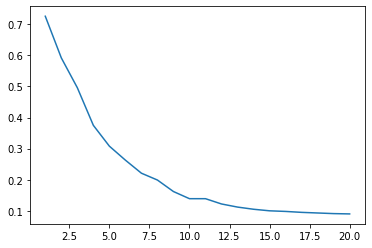

In [18]:
plt.plot(np.arange(1,21),imbis[:,1])

In [19]:
var

[[10],
 [16, 10],
 [16, 15, 23],
 [16, 10, 23, 15],
 [10, 15, 16, 23, 24],
 [10, 12, 15, 16, 23, 24],
 [10, 12, 15, 16, 17, 23, 24],
 [10, 12, 15, 16, 17, 18, 23, 24],
 [5, 10, 12, 15, 16, 17, 18, 23, 24],
 [5, 7, 10, 12, 15, 16, 17, 18, 23, 24],
 [5, 10, 12, 13, 15, 16, 17, 18, 19, 23, 24],
 [5, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [5, 7, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [4, 5, 7, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [1, 4, 5, 7, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [3, 4, 5, 7, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [0, 3, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [0, 1, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24],
 [0, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 24],
 [0, 1, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 24]]

In [26]:
imbis

array([[0.45, 0.73],
       [0.29, 0.59],
       [0.2 , 0.5 ],
       [0.16, 0.38],
       [0.13, 0.31],
       [0.11, 0.26],
       [0.1 , 0.22],
       [0.09, 0.2 ],
       [0.09, 0.16],
       [0.09, 0.14],
       [0.07, 0.14],
       [0.07, 0.12],
       [0.07, 0.11],
       [0.07, 0.1 ],
       [0.07, 0.1 ],
       [0.07, 0.1 ],
       [0.07, 0.1 ],
       [0.07, 0.09],
       [0.07, 0.09],
       [0.07, 0.09]])

In [23]:
np.array(names)[var[0]]

array(['psi2'], dtype='<U7')

In [24]:
np.array(names)[var[7]]

array(['psi2', 'psi4', 'psi7', 'psi8', 'psi9', 'chi1_1', 'chi1_9',
       'chi1_10'], dtype='<U7')